In [100]:
import sys, os

os.add_dll_directory(r"C:\Program Files\KiCad\10.0\bin")
sys.path.insert(0, r"C:\Program Files\KiCad\10.0\bin\Lib\site-packages")

import pcbnew
from kikit.panelize import Panel, Origin
from kikit.common import findBoardBoundingBox
from kikit.units import mm
from shapely.geometry import LineString, box

print("pcbnew", pcbnew.Version(), "| mm =", mm, "IU")


pcbnew 10.0.1 | mm = 1000000 IU


%% [cell 2] Paths + ensure output directory exists

In [101]:
BASE = r"C:\Users\Shaheen\Desktop\Projects\PCB\Keyboard\design\2layer"

LEFT_PCB  = os.path.join(BASE, "leftside",  "leftside.kicad_pcb")
RIGHT_PCB = os.path.join(BASE, "rightside", "rightside.kicad_pcb")
OUT_DIR   = os.path.join(BASE, "merged")
PANEL_PCB = os.path.join(OUT_DIR, "merged.kicad_pcb")

os.makedirs(OUT_DIR, exist_ok=True)  # Panel() requires the output dir to exist

for p in (LEFT_PCB, RIGHT_PCB):
    print(("OK  " if os.path.exists(p) else "MISSING ") + p)
print("OUT ", PANEL_PCB)

OK  C:\Users\Shaheen\Desktop\Projects\PCB\Keyboard\design\2layer\leftside\leftside.kicad_pcb
OK  C:\Users\Shaheen\Desktop\Projects\PCB\Keyboard\design\2layer\rightside\rightside.kicad_pcb
OUT  C:\Users\Shaheen\Desktop\Projects\PCB\Keyboard\design\2layer\merged\merged.kicad_pcb


%% [cell 3] Tunable parameters

In [102]:
GAP        = 0.5 * mm     # routed slot between the halves (raise toward ~1.0 if JLC flags slot width)
TAB_W      = 3.0 * mm     # FR4 bridge (tab) width
OVERLAP    = 0.1 * mm     # how far each bridge bites into the boards (ensures a clean union)
MB_DIAM    = 0.5 * mm     # mouse-bite hole diameter
MB_SPACING = 0.8 * mm     # mouse-bite hole centre-to-centre spacing
EDGE_CLEAR = 0.5 * mm     # FINDER ONLY: copper this close (Y) to the slot vetoes a tab window
KEEP_BITE  = 0.0 * mm     # how far the copper keepout eats INTO each board (0 = leave board untouched)
XCLEAR     = 0.5 * mm     # X-margin subtracted around each copper blocker
MIN_TAB    = 3.0 * mm     # minimum usable window width
EPS        = int(0.02 * mm)


%% [cell 4] Visualisation helper

In [103]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import MultiPolygon

BOARD_COLORS = ["#AED6F1", "#A9DFBF"]

def _fill(ax, poly, color, alpha=0.55):
    if isinstance(poly, MultiPolygon):
        for g in poly.geoms:
            _fill(ax, g, color, alpha)
        return
    if poly.is_empty:
        return
    xs = [v / mm for v in poly.exterior.coords.xy[0]]
    ys = [v / mm for v in poly.exterior.coords.xy[1]]
    ax.fill(xs, ys, color=color, alpha=alpha, zorder=2)
    ax.plot(xs, ys, color="#333", linewidth=0.8, zorder=3)

def show(panel, title="Panel", windows=None, bridges=None, keepouts=None, holes=None):
    fig, ax = plt.subplots(figsize=(7, 10))
    handles = []

    for i, sub in enumerate(panel.substrates):
        c = BOARD_COLORS[i % len(BOARD_COLORS)]
        _fill(ax, sub.substrates, c)
        handles.append(mpatches.Patch(color=c, label=f"Board {i + 1}"))

    merged = panel.boardSubstrate.substrates
    if not merged.is_empty:
        for g in (merged.geoms if isinstance(merged, MultiPolygon) else [merged]):
            ax.plot([v / mm for v in g.exterior.coords.xy[0]],
                    [v / mm for v in g.exterior.coords.xy[1]],
                    color="black", linewidth=2.0, zorder=5)
        handles.append(mpatches.Patch(facecolor="none", edgecolor="black", label="Edge.Cuts"))

    b = panel.boardSubstrate.boundingBox()
    x0, x1 = b.GetX() / mm, (b.GetX() + b.GetWidth()) / mm

    if windows:
        for lo, hi in windows:
            ax.axvspan(lo / mm, hi / mm, color="green", alpha=0.12, zorder=1)
        handles.append(mpatches.Patch(color="green", alpha=0.2, label="tab windows"))
    if keepouts:
        for k in keepouts:
            mnx, mny, mxx, mxy = k.bounds
            ax.add_patch(mpatches.Rectangle((mnx / mm, mny / mm), (mxx - mnx) / mm,
                         (mxy - mny) / mm, facecolor="orange", edgecolor="darkorange",
                         linewidth=1.5, alpha=0.75, zorder=6,
                         hatch="////"))
        handles.append(mpatches.Patch(facecolor="orange", edgecolor="darkorange",
                       hatch="////", alpha=0.75, label="copper keepout"))
    if bridges:
        for br in bridges:
            mnx, mny, mxx, mxy = br.bounds
            ax.add_patch(mpatches.Rectangle((mnx / mm, mny / mm), (mxx - mnx) / mm,
                         (mxy - mny) / mm, facecolor="#1E8449", edgecolor="#145A32", zorder=6))
        handles.append(mpatches.Patch(color="#1E8449", label="tab (bridge)"))
    if holes:
        ax.scatter([h.x / mm for h in holes], [h.y / mm for h in holes],
                   s=12, color="white", edgecolors="black", linewidths=0.6, zorder=7)
        handles.append(mpatches.Patch(facecolor="white", edgecolor="black", label="mouse-bite holes"))

    ax.set_aspect("equal")
    ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)")
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend(handles=handles, loc="upper right", fontsize=8)
    ax.set_title(title)
    ax.set_xlim(x0 - 5, x1 + 5)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

%% [cell 5] Create panel + place both halves (right half rotated 180°), with GAP

Inherited design settings from left board | copper-to-edge = 0.2 mm | min clearance = 0.12 mm
Slot Y:[113.06, 113.56]  (gap 0.50 mm)


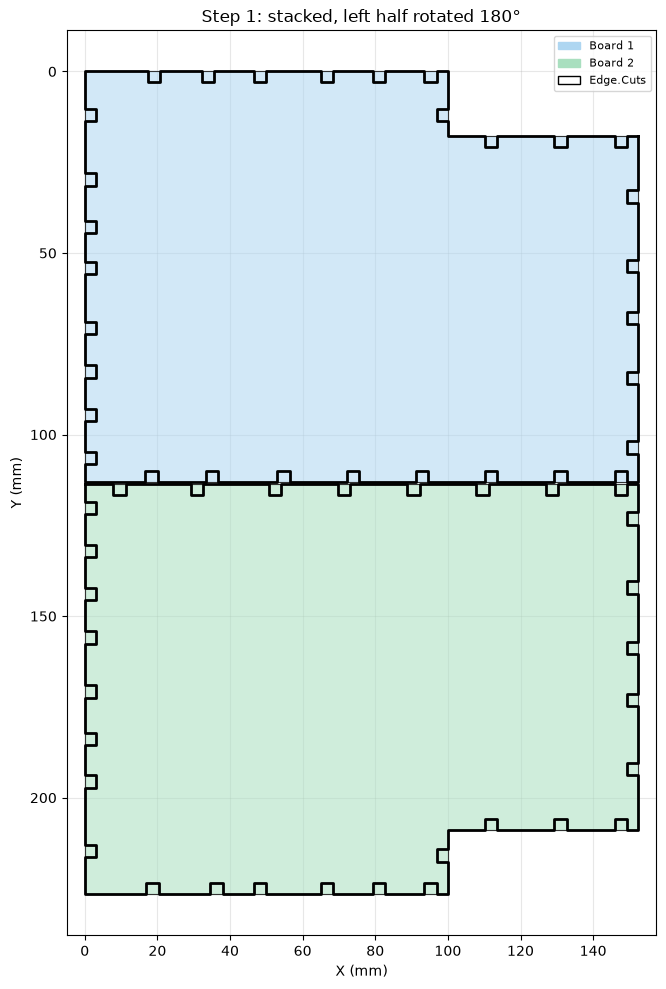

In [104]:
panel = Panel(PANEL_PCB)

# Which half is flipped 180°? Exactly one half is rotated so the two mirror-image
# halves tile. Flip this to rotate the LEFT half instead of the RIGHT.
ROTATE_LEFT = True
ROT_180 = pcbnew.EDA_ANGLE(180, pcbnew.DEGREES_T)

def place(path, y_top, rotate, inheritDrc=False):
    """Place a board left-aligned at X=0 with its TOP edge at y_top, optionally
    flipped 180°, and return its placed BOX2I. Handles the origin math:
    Origin.TopLeft + 180° makes a WxH board span (destX-W, destY-H)..(destX, destY),
    so to land it at X:[0,W], Y:[y_top, y_top+H] we aim dest at (W, y_top+H).
    Unrotated, the top-left simply goes to (0, y_top)."""
    bb = findBoardBoundingBox(pcbnew.LoadBoard(path))
    W, H = bb.GetWidth(), bb.GetHeight()
    if rotate:
        dest = pcbnew.VECTOR2I(W, y_top + H)
        return panel.appendBoard(path, dest, origin=Origin.TopLeft,
                                 rotationAngle=ROT_180, inheritDrc=inheritDrc)
    return panel.appendBoard(path, pcbnew.VECTOR2I(0, y_top),
                             origin=Origin.TopLeft, inheritDrc=inheritDrc)

# Left half on top, right half below, joined on the 152 mm long edge with a
# routed GAP between. Exactly one half is rotated (ROTATE_LEFT picks which).
b1 = place(LEFT_PCB,  0,      rotate=ROTATE_LEFT,       inheritDrc=False)
SEAM1 = b1.GetY() + b1.GetHeight()   # bottom edge of the top half
SEAM2 = SEAM1 + int(GAP)             # top edge of the bottom half (slot between)
b2 = place(RIGHT_PCB, SEAM2,  rotate=not ROTATE_LEFT,   inheritDrc=False)

# Two layers carry design rules:
#   - the .kicad_pro project file  -> what KiCad's Board Setup shows & DRC uses
#       (handled in cell 8 by copying leftside.kicad_pro over the panel's .kicad_pro)
#   - the .kicad_pcb (setup) block -> what save()'s in-memory zone REFILL uses
# CloneFrom handles the second: without it the refill uses NewBoard defaults
# (e.g. 0.5 mm edge clearance) and eats your edge copper.
_src_ds = pcbnew.LoadBoard(LEFT_PCB).GetDesignSettings()
panel.board.GetDesignSettings().CloneFrom(_src_ds)   # copies all 69 settings; reference write sticks
print("Inherited design settings from left board | copper-to-edge =",
      panel.board.GetDesignSettings().m_CopperEdgeClearance / mm, "mm",
      "| min clearance =", panel.board.GetDesignSettings().m_MinClearance / mm, "mm")

print(f"Slot Y:[{SEAM1/mm:.2f}, {SEAM2/mm:.2f}]  (gap {GAP/mm:.2f} mm)")
show(panel, f"Step 1: stacked, {'left' if ROTATE_LEFT else 'right'} half rotated 180°")

%% [cell 6] Auto-find copper-clear tab windows along the slot

6 viable tab window(s):
  X:[  22.27,   27.06]  width  4.79 mm  center   24.66 mm
  X:[  38.94,   48.49]  width  9.55 mm  center   43.71 mm
  X:[  58.67,   67.54]  width  8.87 mm  center   63.10 mm
  X:[  77.72,   86.59]  width  8.87 mm  center   82.15 mm
  X:[  99.61,  105.64]  width  6.03 mm  center  102.62 mm
  X:[ 115.82,  124.69]  width  8.87 mm  center  120.25 mm


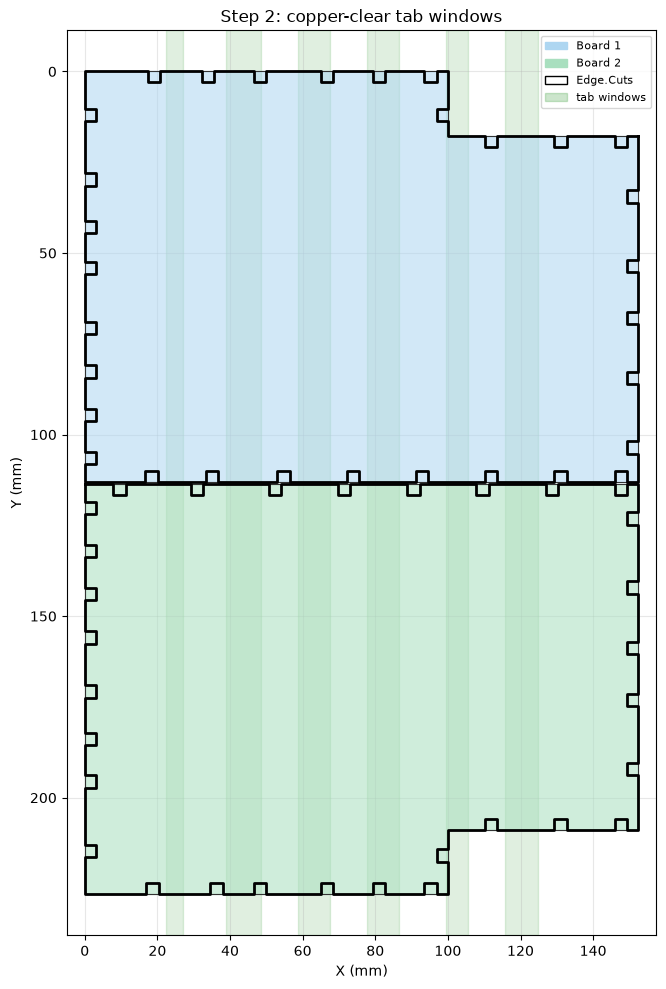

In [105]:
def _solid_runs(poly, edge_y, inside):
    line = LineString([(panel.boardSubstrate.boundingBox().GetX(), edge_y + inside),
                       (panel.boardSubstrate.boundingBox().GetX()
                        + panel.boardSubstrate.boundingBox().GetWidth(), edge_y + inside)])
    runs = []
    for g in getattr(poly.intersection(line), "geoms", [poly.intersection(line)]):
        if g.is_empty:
            continue
        xs = [c[0] for c in g.coords]
        runs.append([min(xs), max(xs)])
    runs.sort()
    return runs

def _intersect(a, b):
    out = []
    for a0, a1 in a:
        for b0, b1 in b:
            lo, hi = max(a0, b0), min(a1, b1)
            if hi > lo:
                out.append([lo, hi])
    out.sort()
    return out

def _ydist_to_slot(top, bot):
    if bot >= SEAM1 and top <= SEAM2:        # overlaps the slot
        return 0.0
    return min(abs(top - SEAM2), abs(bot - SEAM1))

def find_tab_windows():
    # seam material present on BOTH halves (board1 just above SEAM1, board2 just below SEAM2)
    mutual = _intersect(_solid_runs(panel.substrates[0].substrates, SEAM1, -EPS),
                        _solid_runs(panel.substrates[1].substrates, SEAM2,  EPS))

    blocked = []
    for fp in panel.board.GetFootprints():
        for pad in fp.Pads():
            if not pad.IsOnCopperLayer():
                continue
            pbb = pad.GetBoundingBox()
            if _ydist_to_slot(pbb.GetY(), pbb.GetY() + pbb.GetHeight()) < EDGE_CLEAR:
                blocked.append([pbb.GetX() - XCLEAR, pbb.GetX() + pbb.GetWidth() + XCLEAR])
    for t in panel.board.GetTracks():
        if not pcbnew.IsCopperLayer(t.GetLayer()):
            continue
        ys = sorted((t.GetStart().y, t.GetEnd().y))
        if _ydist_to_slot(ys[0], ys[1]) < EDGE_CLEAR:
            xs = sorted((t.GetStart().x, t.GetEnd().x))
            blocked.append([xs[0] - XCLEAR, xs[1] + XCLEAR])
    # rule areas / keepouts (e.g. the antenna keepout) block tabs too. Draw a
    # rule area in KiCad over any spot you want to keep tab-free. We skip the
    # keepouts this script adds itself so re-runs stay correct.
    for zone in panel.board.Zones():
        if not zone.GetIsRuleArea() or zone.GetZoneName() == "KIKIT_MB_KEEPOUT":
            continue
        zbb = zone.GetBoundingBox()
        if _ydist_to_slot(zbb.GetY(), zbb.GetY() + zbb.GetHeight()) < EDGE_CLEAR:
            blocked.append([zbb.GetX() - XCLEAR, zbb.GetX() + zbb.GetWidth() + XCLEAR])

    def subtract(runs, blocks):
        res = []
        for r0, r1 in runs:
            segs = [[r0, r1]]
            for b0, b1 in blocks:
                new = []
                for s0, s1 in segs:
                    if b1 <= s0 or b0 >= s1:
                        new.append([s0, s1])
                    else:
                        if s0 < b0: new.append([s0, b0])
                        if b1 < s1: new.append([b1, s1])
                segs = new
            res.extend(segs)
        return res

    return [tuple(s) for s in subtract(mutual, blocked) if s[1] - s[0] >= MIN_TAB]

WINDOWS = find_tab_windows()
print(f"{len(WINDOWS)} viable tab window(s):")
for lo, hi in WINDOWS:
    print(f"  X:[{lo/mm:7.2f}, {hi/mm:7.2f}]  width {(hi-lo)/mm:5.2f} mm  center {((lo+hi)/2)/mm:7.2f} mm")
show(panel, "Step 2: copper-clear tab windows", windows=WINDOWS)


[cell 7] Build a tab + keepout at each window centre, then mouse-bite

6 tabs, 24 mouse-bite holes


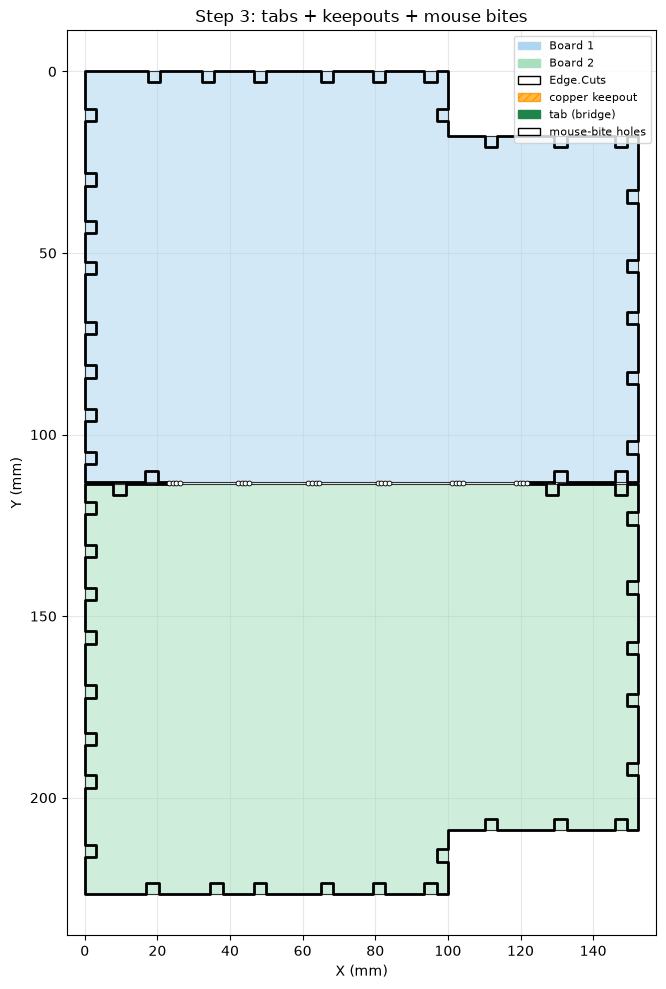

In [106]:
BRIDGES, KEEPOUTS, CUTS = [], [], []
for lo, hi in WINDOWS:
    c = (lo + hi) / 2
    w = min(TAB_W, hi - lo)
    # FR4 bridge across the slot, biting OVERLAP into each board so the union is clean
    bridge = box(c - w / 2, SEAM1 - OVERLAP, c + w / 2, SEAM2 + OVERLAP)
    panel.appendSubstrate(bridge)
    BRIDGES.append(bridge)
    # copper keepout: spans the slot, biting only KEEP_BITE into each board
    midY = (SEAM1 + SEAM2) / 2
    keep = box(c - w / 2, SEAM1 - KEEP_BITE,
               c + w / 2, SEAM2 + KEEP_BITE)
    KEEPOUTS.append(keep)
    _kz = panel.addKeepout(keep)
    _kz.SetZoneName("KIKIT_MB_KEEPOUT")
    # perforation line down the middle of the slot, spanning the bridge width
    midY = (SEAM1 + SEAM2) / 2
    CUTS.append(LineString([(c - w / 2, midY), (c + w / 2, midY)]))

panel.makeMouseBites(CUTS, diameter=int(MB_DIAM), spacing=int(MB_SPACING),
                     offset=0, prolongation=0)

# recompute hole positions for the preview (mirrors makeMouseBites' interpolation)
HOLES = []
_sub = panel.boardSubstrate.substrates
for cut in CUTS:
    n = max(int(cut.length / MB_SPACING) + 1, 1)
    pts = [cut.interpolate(0.5, normalized=True)] if n == 1 else \
          [cut.interpolate(i * cut.length / (n - 1)) for i in range(n)]
    HOLES += [p for p in pts if _sub.intersects(p)]

print(f"{len(BRIDGES)} tabs, {len(HOLES)} mouse-bite holes")
show(panel, "Step 3: tabs + keepouts + mouse bites",
     bridges=BRIDGES, keepouts=KEEPOUTS, holes=HOLES)

%% [cell 8] Save (refill zones so the keepouts pull the pour back)

In [107]:
import shutil, json
panel.save(refillAllZones=True)
print("Saved:", PANEL_PCB)

# Give the panel the left board's FULL project rules: overwrite the panel's
# .kicad_pro (which KiCad's Board Setup / DRC reads) with the left board's.
_src_pro = os.path.splitext(LEFT_PCB)[0] + ".kicad_pro"
_dst_pro = os.path.splitext(PANEL_PCB)[0] + ".kicad_pro"
shutil.copyfile(_src_pro, _dst_pro)
print("Cloned project rules from:", _src_pro)

# KiKit renamed every net to "Board_{i}-{orig}", so the copied net-class
# assignments/patterns (keyed by the ORIGINAL names) no longer match -> custom
# net-class constraints are lost and DRC complains. Re-key them onto every
# board-prefix so e.g. /RF -> Board_0-/RF and Board_1-/RF keep the ANT class.
_prefixes = [f"Board_{i}-" for i in range(len(panel.substrates))]
with open(_dst_pro, encoding="utf-8") as f:
    _proj = json.load(f)
_ns = _proj.setdefault("net_settings", {})

_orig_assign = _ns.get("netclass_assignments") or {}
_orig_patterns = _ns.get("netclass_patterns") or []

# Keep the prefixed explicit assignments...
_ns["netclass_assignments"] = {
    pre + net: cls for net, cls in _orig_assign.items() for pre in _prefixes
}
# ...but ALSO express each membership as an exact-net-name PATTERN. KiCad's Net
# Classes tab shows/applies patterns, not assignments; these names contain no
# * or ? so they match their net literally.
_ns["netclass_patterns"] = (
    [{**p, "pattern": pre + p["pattern"]} for p in _orig_patterns for pre in _prefixes]
    + [{"netclass": c, "pattern": pre + net}
       for net, classes in _orig_assign.items() for c in classes for pre in _prefixes]
)
with open(_dst_pro, "w", encoding="utf-8") as f:
    json.dump(_proj, f, indent=2)
print(f"Net-class refs re-keyed for {_prefixes}: "
      f"{len(_ns['netclass_assignments'])} assignments, "
      f"{len(_ns['netclass_patterns'])} patterns")
if panel.hasErrors():
    print("!! panel errors (see Margin layer):")
    for _, msg in panel.errors:
        print("  -", msg.splitlines()[0])
else:
    print("No panelisation errors.")

Saved: C:\Users\Shaheen\Desktop\Projects\PCB\Keyboard\design\2layer\merged\merged.kicad_pcb
Cloned project rules from: C:\Users\Shaheen\Desktop\Projects\PCB\Keyboard\design\2layer\leftside\leftside.kicad_pro
Net-class refs re-keyed for ['Board_0-', 'Board_1-']: 18 assignments, 18 patterns
No panelisation errors.


In [108]:
import os, json, shutil
pro = os.path.splitext(PANEL_PCB)[0] + ".kicad_pro"
print("PANEL_PCB :", PANEL_PCB, "| exists:", os.path.exists(PANEL_PCB))
print("panel .pro:", pro, "| exists:", os.path.exists(pro))

src_pro = os.path.splitext(LEFT_PCB)[0] + ".kicad_pro"
print("left  .pro:", src_pro, "| exists:", os.path.exists(src_pro))

if os.path.exists(pro):
    j = json.load(open(pro))
    print("panel rules NOW:", j.get("board", {}).get("design_settings", {}).get("rules"))

left = os.path.splitext(LEFT_PCB)[0] + ".kicad_pro"
if os.path.exists(left):
    j = json.load(open(left))
    print("left rules NOW:", j.get("board", {}).get("design_settings", {}).get("rules"))

PANEL_PCB : C:\Users\Shaheen\Desktop\Projects\PCB\Keyboard\design\2layer\merged\merged.kicad_pcb | exists: True
panel .pro: C:\Users\Shaheen\Desktop\Projects\PCB\Keyboard\design\2layer\merged\merged.kicad_pro | exists: True
left  .pro: C:\Users\Shaheen\Desktop\Projects\PCB\Keyboard\design\2layer\leftside\leftside.kicad_pro | exists: True
panel rules NOW: {'max_error': 0.005, 'min_clearance': 0.12, 'min_connection': 0.1, 'min_copper_edge_clearance': 0.2, 'min_groove_width': 0.0, 'min_hole_clearance': 0.2, 'min_hole_to_hole': 0.45, 'min_microvia_diameter': 0.25, 'min_microvia_drill': 0.15, 'min_resolved_spokes': 1, 'min_silk_clearance': 0.0, 'min_text_height': 1.0, 'min_text_thickness': 0.15, 'min_through_hole_diameter': 0.2, 'min_track_width': 0.1, 'min_via_annular_width': 0.05, 'min_via_diameter': 0.25, 'solder_mask_to_copper_clearance': 0.005, 'use_height_for_length_calcs': True}
left rules NOW: {'max_error': 0.005, 'min_clearance': 0.12, 'min_connection': 0.1, 'min_copper_edge_cleara